#### 1. DOWNLOADING DATA

In [1]:
# importing necessary library
import torch 
from torch import nn

print(f"Version of torch: {torch.__version__}")

Version of torch: 2.10.0+cu128


In [2]:
!nvidia-smi

Thu Mar 26 11:35:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Setting device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# # Downloading data 
# import requests
# import zipfile
# from pathlib import Path

# # Setup path to data folder
# data_path = Path("data/")
# image_path = data_path / "pizza_steak_sushi"

# # If the image folder doesn't exist, download it and prepare it... 
# if image_path.is_dir():
#     print(f"{image_path} directory exists.")
# else:
#     print(f"Did not find {image_path} directory, creating one...")
#     image_path.mkdir(parents=True, exist_ok=True)
    
#     # Download pizza, steak, sushi data
#     with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
#         request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
#         print("Downloading pizza, steak, sushi data...")
#         f.write(request.content)

#     # Unzip pizza, steak, sushi data
#     with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
#         print("Unzipping pizza, steak, sushi data...") 
#         zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


#### 2. VISUALIZE IMAGE

In [25]:
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"
image_path

PosixPath('data/pizza_steak_sushi')

In [26]:
import os
def walk_through_dir(dir_path):
    for dirpath, dirname, filenames in os.walk(dir_path):
        print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}")

In [27]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza


In [8]:
train_dir = image_path/ "train"
test_dir = image_path/ "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [24]:
image_path_list = list(image_path.glob('*/*/*.jpg'))
image_path_list

[PosixPath('data/pizza_steak_sushi/train/sushi/2797464.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/170385.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2574453.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/542188.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1232045.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/710379.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1214108.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2980779.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/93139.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2021685.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/390178.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2019344.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/821108.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/765684.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/307738.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2873571.jpg'),
 PosixPath('data/

Image path: data/pizza_steak_sushi/train/sushi/2267190.jpg
Class name: sushi
Height: 512
Width: 512


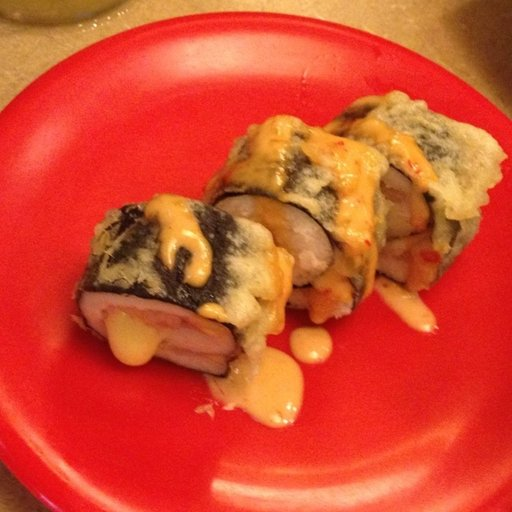

In [19]:
import random 
from PIL import Image 

random.seed(42)

image_path_list = list(image_path.glob('*/*/*.jpg'))

random_image_path = random.choice(image_path_list)
# print(random_image_path)

image_class = random_image_path.parent.stem
# print(image_class)

img = Image.open(random_image_path)
print(f"Image path: {random_image_path}")
print(f"Class name: {image_class}")
print(f"Height: {img.height}")
print(f"Width: {img.width}")
img

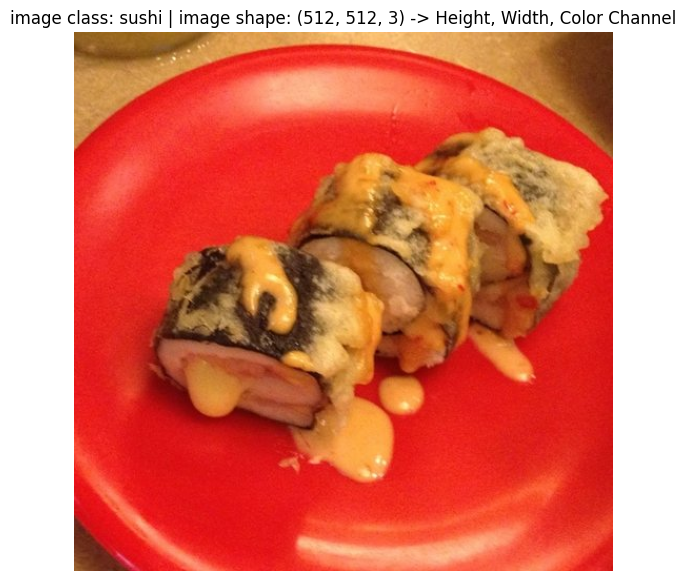

In [23]:
import numpy as np 
import matplotlib.pyplot as plt 

image_array = np.asarray(img)
plt.figure(figsize=(10,7))
plt.imshow(image_array)
plt.title(f"image class: {image_class} | image shape: {image_array.shape} -> Height, Width, Color Channel")
plt.axis("off")
plt.show()